In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving supplement[1].csv to supplement[1].csv


In [ ]:
import os
os.rename("supplement[1].csv", "supplement.csv")

In [ ]:
dataset = pd.read_csv("supplement.csv")

In [ ]:
import os
print(os.listdir())

['.config', 'supplement.csv', 'sample_data']


In [ ]:
dataset = pd.read_csv("supplement.csv")
dataset.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB


In [ ]:
dataset.isnull().sum()

,0
ID,0
Store_id,0
Store_Type,0
Location_Type,0
Region_Code,0
Date,0
Holiday,0
Discount,0
#Order,0
Sales,0


In [ ]:
dataset.describe()

,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


In [ ]:
pie = dataset["Store_id"].value_counts()

fig = px.pie(values=pie.values, names=pie.index, title="Store ID Distribution")
fig.show()

In [ ]:
pie = dataset["Store_Type"].value_counts()

fig = px.pie(values=pie.values, names=pie.index, title="Store Type Distribution")
fig.show()

In [ ]:
pie = dataset["Location_Type"].value_counts()

fig = px.pie(values=pie.values, names=pie.index, title="Location Type Distribution")
fig.show()

In [ ]:
pie = dataset["Discount"].value_counts()

fig = px.pie(values=pie.values, names=pie.index, title="Discount Distribution")
fig.show()

In [ ]:
pie = dataset["Holiday"].value_counts()

fig = px.pie(values=pie.values, names=pie.index, title="Holiday Distribution")
fig.show()

In [ ]:
dataset["Discount"] = dataset["Discount"].map({"No": 0, "Yes": 1})
dataset["Holiday"] = dataset["Holiday"].map({"No": 0, "Yes": 1})
dataset["Store_Type"] = dataset["Store_Type"].map({"S1": 1, "S2": 2, "S3": 3, "S4": 4})
dataset["Location_Type"] = dataset["Location_Type"].map({"L1": 1, "L2": 2, "L3": 3, "L4": 4, "L5": 5})

dataset.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,1,3,R1,2018-01-01,NaN,1,9,7011.84
1,T1000002,253,4,2,R1,2018-01-01,NaN,1,60,51789.12
2,T1000003,252,3,2,R1,2018-01-01,NaN,1,42,36868.20
3,T1000004,251,2,3,R1,2018-01-01,NaN,1,23,19715.16
4,T1000005,250,2,3,R4,2018-01-01,NaN,1,62,45614.52


In [ ]:
X = np.array(dataset[["Store_Type", "Location_Type", "Holiday", "Discount"]])
y = np.array(dataset["#Order"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import lightgbm as ltb

model = ltb.LGBMRegressor()
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13
[LightGBM] [Info] Number of data points in the train set: 150672, number of used features: 3
[LightGBM] [Info] Start training from score 68.163401
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMRegressor()

In [ ]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 13.605072204466746
MSE: 401.2280011374149


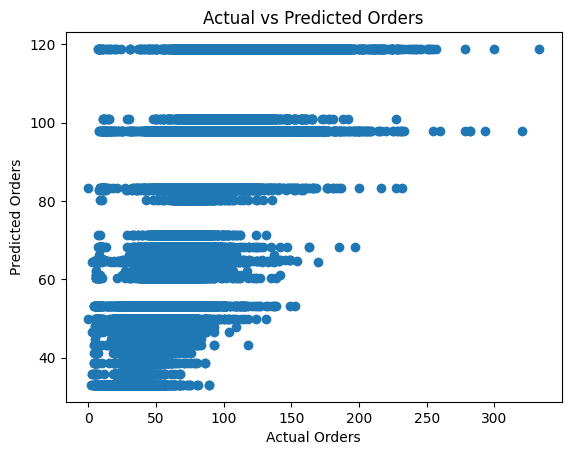

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("Actual vs Predicted Orders")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual Orders": y_test,
    "Predicted Orders": y_pred
})

results.head()

,Actual Orders,Predicted Orders
0,54,46.614754
1,111,118.819020
2,59,64.710178
3,67,83.203649
4,60,53.279009


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": ["Store_Type", "Location_Type", "Holiday", "Discount"],
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
1,Location_Type,2000
3,Discount,400
0,Store_Type,300
2,Holiday,0


In [ ]:
dataset.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,1,3,R1,2018-01-01,NaN,1,9,7011.84
1,T1000002,253,4,2,R1,2018-01-01,NaN,1,60,51789.12
2,T1000003,252,3,2,R1,2018-01-01,NaN,1,42,36868.20
3,T1000004,251,2,3,R1,2018-01-01,NaN,1,23,19715.16
4,T1000005,250,2,3,R4,2018-01-01,NaN,1,62,45614.52


In [ ]:
dataset["Location_Type"] = dataset["Location_Type"].map({
    "L1": 1, "L2": 2, "L3": 3, "L4": 4, "L5": 5
})

In [ ]:
dataset["Holiday"] = dataset["Holiday"].map({"No": 0, "Yes": 1})

In [ ]:
dataset.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,1,NaN,R1,2018-01-01,NaN,1,9,7011.84
1,T1000002,253,4,NaN,R1,2018-01-01,NaN,1,60,51789.12
2,T1000003,252,3,NaN,R1,2018-01-01,NaN,1,42,36868.20
3,T1000004,251,2,NaN,R1,2018-01-01,NaN,1,23,19715.16
4,T1000005,250,2,NaN,R4,2018-01-01,NaN,1,62,45614.52


In [ ]:
X = np.array(dataset[["Store_Type", "Location_Type", "Holiday", "Discount"]])
y = np.array(dataset["#Order"])

In [ ]:
X

array([[ 1., nan, nan,  1.],
       [ 4., nan, nan,  1.],
       [ 3., nan, nan,  1.],
       ...,
       [ 1., nan, nan,  0.],
       [ 3., nan, nan,  1.],
       [ 2., nan, nan,  0.]])

In [ ]:
y

array([ 9, 60, 42, ..., 56, 70, 47])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
len(X_train)

150672

In [ ]:
import lightgbm as ltb

model = ltb.LGBMRegressor()
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007681 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7
[LightGBM] [Info] Number of data points in the train set: 150672, number of used features: 2
[LightGBM] [Info] Start training from score 68.163401
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMRegressor()

In [ ]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



In [ ]:
y_pred

array([ 52.47402214, 113.35879222,  64.86941414, ...,  52.47402214,
        52.47402214,  82.71949219])

In [ ]:
y_test

array([ 54, 111,  59, ...,  40,  69,  68])

In [ ]:
data = pd.DataFrame({
    "Actual Orders": y_test,
    "Predicted Orders": y_pred
})

data.head()

,Actual Orders,Predicted Orders
0,54,52.474022
1,111,113.358792
2,59,64.869414
3,67,93.477860
4,60,52.474022


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 13.975615210932045
MSE: 420.5880651285726


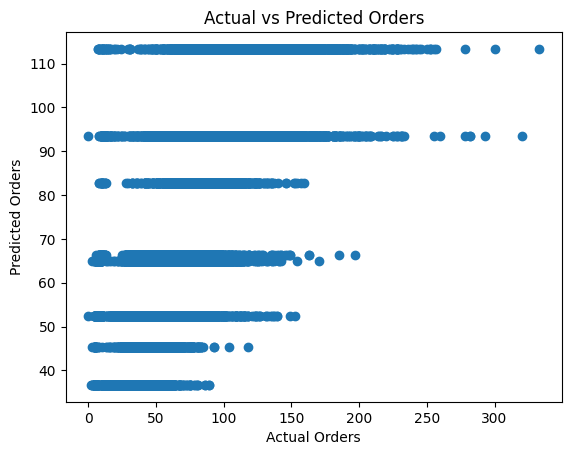

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("Actual vs Predicted Orders")
plt.show()

In [ ]:
data = pd.DataFrame({
    "Actual Orders": y_test,
    "Predicted Orders": y_pred.flatten()
})

data.head()

,Actual Orders,Predicted Orders
0,54,52.474022
1,111,113.358792
2,59,64.869414
3,67,93.477860
4,60,52.474022
